# Simple Coupled

This tutorial demonstrates a **simple coupled** controlled pendulum assembled from FMI 2.0 Co-Simulation FMUs wrapped by `FMUComponent`.

It is *simple coupled* because there is **no algebraic loop** between the actuator (`drive`) and the plant (`pendulum`): the plant provides `omega` back to the drive, but the control torque sent to the plant is not an instantaneous algebraic function of the plant torque.


## Overview

We build a closed-loop pendulum controller with the following FMU-based components:

- `ref`: reference trajectory generator
- `sensor_ref`: encoder on the reference signal
- `sensor_state`: encoder on the pendulum angle
- `pid`: continuous PID controller
- `drive`: actuator dynamics and limits
- `pendulum`: physical pendulum model

This notebook focuses on **core framework capabilities**:

- FMU composition via `System`
- explicit signal wiring via `Connection`
- initialization, execution order, and loop inspection
- history access and post-processing
- a compact but illustrative **PID parameter study**

Later tutorials can swap the pendulum FMU with higher-fidelity models (FEM, OpenSim, or master-level models) without changing the orchestration pattern.


## Learning Goals

By the end of this tutorial, you should be able to:

- assemble an FMU-based closed-loop system
- confirm that the system is simple coupled (no algebraic loops)
- run a time simulation and access component histories
- compare controller parameter sets with simple performance metrics


## Prerequisites and Setup

We rely on:

- `syssimx`
- `numpy`
- `pandas`
- `matplotlib`
- `graphviz` (optional, for the system diagram)


In [195]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from syssimx import FMUComponent, System, Connection
from syssimx.viz.sysgraph import SystemGraphVisualizer


## Discover FMUs

We locate the pendulum case study FMUs from the repository.


In [208]:
repo_root = Path().cwd().parent.parent.parent
fmu_dir = repo_root / "demos/ControlledPendulum/MyModels/FMUs"

fmu_files = sorted(fmu_dir.glob("*.fmu"))
fmu_paths = {f.stem: f for f in fmu_files}

## System Construction

We encapsulate system assembly in helper functions so we can easily rerun the same experiment with different PID parameters.


In [197]:
@dataclass(frozen=True)
class PIDParams:
    k: float
    Ti: float
    Td: float
    Nd: float


def _components(pid_overrides: dict[str, float] | None = None):
    ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Reference")
    sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
    sensor_state = FMUComponent(name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
    pid = FMUComponent(name="pid", fmu_path=fmu_paths["PID_Continuous"], group="Control")
    drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Actuator")
    pendulum = FMUComponent(name="pendulum", fmu_path=fmu_paths["Pendulum"], group="Plant")

    if pid_overrides:
        current = pid.get_parameters("k", "Ti", "Td", "Nd")
        current.update(pid_overrides)
        pid.set_parameters(**current)

    return ref, sensor_ref, sensor_state, pid, drive, pendulum


def _connections(ref, sensor_ref, sensor_state, pid, drive, pendulum):
    c1 = Connection(
        src_comp=ref.name,
        src_port=ref.output_specs["q_ref"].name,
        dst_comp=sensor_ref.name,
        dst_port=sensor_ref.input_specs["q"].name,
    )

    c2 = Connection(
        src_comp=pendulum.name,
        src_port=pendulum.output_specs["q"].name,
        dst_comp=sensor_state.name,
        dst_port=sensor_state.input_specs["q"].name,
    )

    c3 = Connection(
        src_comp=sensor_ref.name,
        src_port=sensor_ref.output_specs["U_q"].name,
        dst_comp=pid.name,
        dst_port=pid.input_specs["ref"].name,
    )

    c4 = Connection(
        src_comp=sensor_state.name,
        src_port=sensor_state.output_specs["U_q"].name,
        dst_comp=pid.name,
        dst_port=pid.input_specs["y"].name,
    )

    c5 = Connection(
        src_comp=pid.name,
        src_port=pid.output_specs["u"].name,
        dst_comp=drive.name,
        dst_port=drive.input_specs["u_control"].name,
    )

    c6 = Connection(
        src_comp=drive.name,
        src_port=drive.output_specs["torque"].name,
        dst_comp=pendulum.name,
        dst_port=pendulum.input_specs["torque"].name,
    )

    c7 = Connection(
        src_comp=pendulum.name,
        src_port=pendulum.output_specs["omega"].name,
        dst_comp=drive.name,
        dst_port=drive.input_specs["omega"].name,
    )

    return [c1, c2, c3, c4, c5, c6, c7]


def build_system(pid_overrides: dict[str, float] | None = None) -> System:
    ref, sensor_ref, sensor_state, pid, drive, pendulum = _components(pid_overrides)
    connections = _connections(ref, sensor_ref, sensor_state, pid, drive, pendulum)

    system = System(name="Simple Coupled Pendulum")
    
    for comp in [ref, sensor_ref, sensor_state, pid, drive, pendulum]:
        system.add_component(comp)
    for conn in connections:
        system.add_connection(conn)

    return system


## Initialize and Inspect Coupling

We initialize once, then inspect execution order and algebraic loops. In a simple coupled system, we expect **no algebraic loops**.


In [198]:
system = build_system()
system.initialize(t0=0.0)

print("\nExecution Order (generations):")
for gen in system.execution_order:
    print(gen)

print("Algebraic Loops:")
for loop in system.algebraic_loops:
    print(loop)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF

Execution Order (generations):
['pendulum', 'ref']
['sensor_ref', 'sens

## Visualize the System Graph

This diagram is useful for verifying signal flow and for communicating model structure.


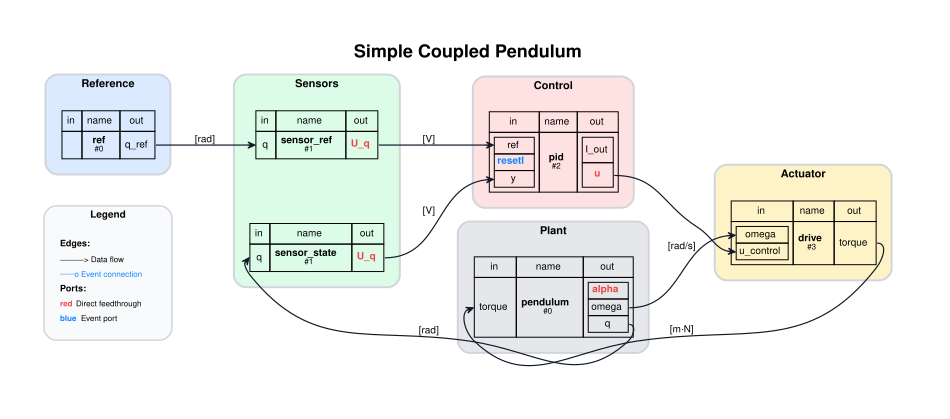

In [199]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("ControlledPendulumSimple.svg")


## Baseline Simulation

We run a baseline simulation using the FMU-provided PID defaults (which are already reasonably tuned).


In [200]:
# Use a fresh system to avoid any state carried over from inspection cells.
baseline_system = build_system()
baseline_system.initialize(t0=0.0)

baseline_system.run(t0=0.0, tf=10.0, dt=0.01)
baseline_history = baseline_system.get_history()


def get_series(history, comp: str, port: str):
    t, data = history.get(comp)
    return t, np.asarray(data[port])


t_ref, q_ref = get_series(baseline_history, "ref", "q_ref")
t_q, q = get_series(baseline_history, "pendulum", "q")
t_u, u = get_series(baseline_history, "pid", "u")


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


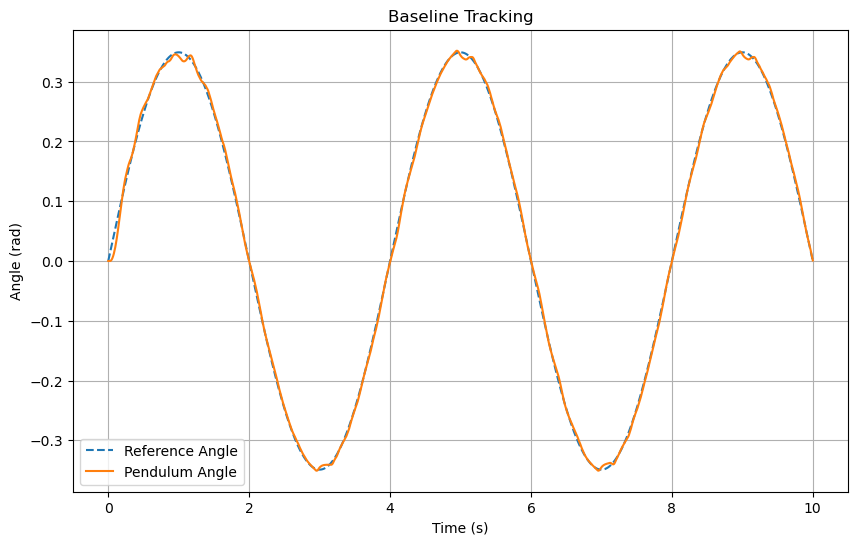

In [201]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, q_ref, "--", label="Reference Angle")
plt.plot(t_q, q, label="Pendulum Angle")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Baseline Tracking")
plt.grid(True)
plt.legend()
plt.show()


## A Small PID Parameter Study

We now explore a few PID parameter sets to illustrate how controller settings affect tracking quality and control effort.

We keep the study intentionally small and readable:

- one baseline (FMU defaults / manually optimized)
- a deliberately conservative setting
- a more aggressive setting
- a PI-only variant (no derivative action)

This is not meant to be exhaustive tuning, but rather a compact demonstration of experimentation workflows in SysSimX.


In [202]:
def run_case(label: str, pid_overrides: dict[str, float], tf: float = 10.0, dt: float = 0.01):
    sys = build_system(pid_overrides)
    sys.initialize(t0=0.0)
    sys.run(t0=0.0, tf=tf, dt=dt)
    hist = sys.get_history()

    t_ref, q_ref = get_series(hist, "ref", "q_ref")
    _, q = get_series(hist, "pendulum", "q")
    _, u = get_series(hist, "pid", "u")

    return {
        "label": label,
        "pid": pid_overrides,
        "t": t_ref,
        "q_ref": q_ref,
        "q": q,
        "u": u
   }


In [203]:
# Start from the FMU defaults so we can report them explicitly.
default_system = build_system()
default_pid = default_system.components['pid'].get_parameters("k", "Ti", "Td", "Nd")
default_pid


{'k': 10.0, 'Ti': 0.05, 'Td': 0.6, 'Nd': 10.0}

In [204]:
pid_cases: list[tuple[str, dict[str, float]]] = [
    ("conservative", {**default_pid, "k": 3.0, "Ti": 0.10, "Td": 0.4, "Nd": 8.0}),
    ("aggressive", {**default_pid, "k": 25.0, "Ti": 0.05, "Td": 0.8, "Nd": 12.0}),
    # PI-only: turn off derivative action while keeping integral action.
    ("pi_only", {**default_pid, "k": 3.0, "Ti": 0.9, "Td": 0.0, "Nd": 1.0}),
]

results = [run_case(label, params) for label, params in pid_cases]


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

### Compare Tracking Performance

We overlay the pendulum trajectories against the common reference.


In [205]:
plotting_styles = {
    "conservative": {"color": "blue", "linestyle": "-"},
    "aggressive": {"color": "red", "linestyle": "-"},
    "pi_only": {"color": "green", "linestyle": "-"},
}

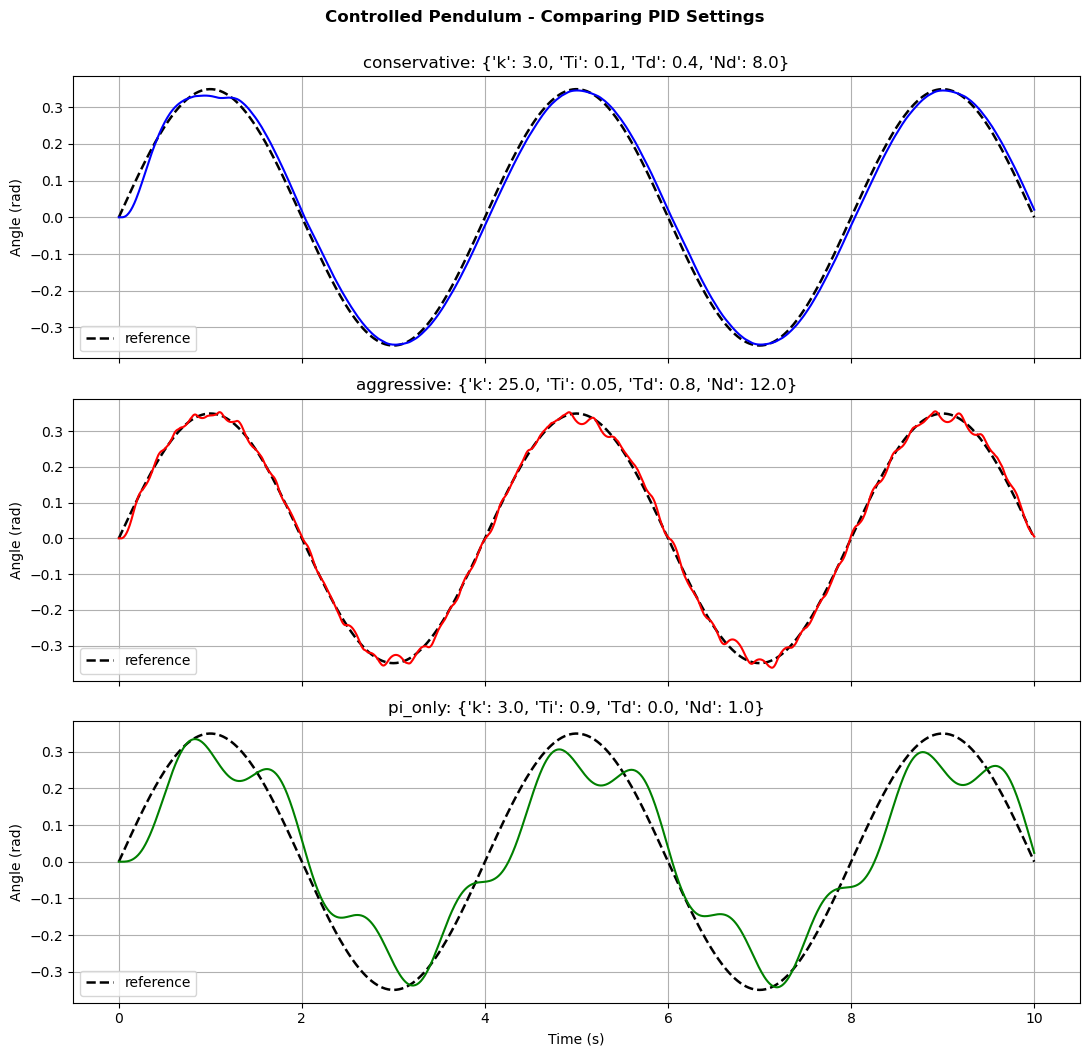

In [206]:
fig, axes = plt.subplots(len(results), 1, figsize=(11, 3.5 * len(results)), sharex=True)
axes = np.atleast_1d(axes)

for ax, r in zip(axes, results):
    ax.plot(r["t"], r["q_ref"], "k--", linewidth=1.8, label="reference")
    ax.plot(r["t"], r["q"], **plotting_styles[r["label"]])
    ax.set_ylabel("Angle (rad)")
    ax.set_title(f"{r['label']}: {r['pid']}")
    ax.grid(True)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Controlled Pendulum - Comparing PID Settings", y=1.001, fontweight='bold')
fig.tight_layout()
plt.show()


### Compare Control Effort

Tracking quality is only half the story; we also inspect controller output magnitude.


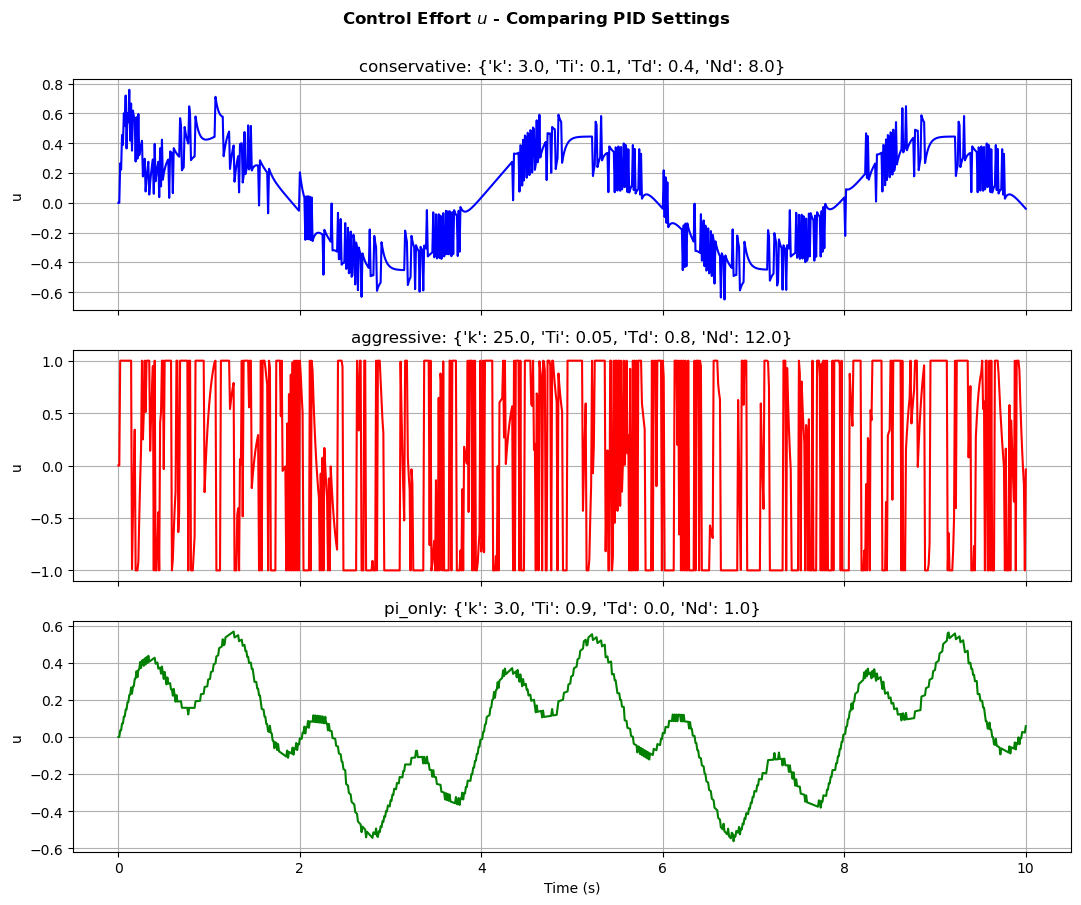

In [207]:
fig, axes = plt.subplots(len(results), 1, figsize=(11, 3.0 * len(results)), sharex=True)
axes = np.atleast_1d(axes)

for ax, r in zip(axes, results):
    ax.plot(r["t"], r["u"], **plotting_styles[r["label"]])
    ax.set_ylabel("u")
    ax.set_title(f"{r['label']}: {r['pid']}")
    ax.grid(True)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Control Effort $u$ - Comparing PID Settings", y=1.001, fontweight='bold')
fig.tight_layout()
plt.show()


## Interpretation

A few practical observations you can confirm from the plots and metrics table:

- increasing `k` typically improves responsiveness but can increase control effort and overshoot
- smaller `Ti` strengthens integral action, often reducing steady-state error but risking oscillation
- derivative action (`Td > 0`) can damp oscillations but may amplify noise in other contexts
